# Test Two-Qubit Gate Sweep Plot

Plot corrected fidelity and latency for the `test_graph_two_qubit_gate_sweep` experiment.


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


In [2]:
line_re = re.compile(
    r"run_id=(?P<run_id>\d+), time to serve=(?P<latency>[-+0-9.eE]+), "
    r"(?:fidelity_raw=(?P<fidelity_raw>[-+0-9.eE]+), fidelity_corrected=(?P<fidelity_corrected>[-+0-9.eE]+), )?"
    r"fidelity=(?P<fidelity>[-+0-9.eE]+)"
)

filename_re = re.compile(
    r"line_(?P<nodes>\d+)_2G,"
    r"code=(?P<code>\[\[.*?\]\]),"
    r"dist=(?P<dist>[0-9.]+),"
    r"gate=(?P<gate>[0-9.]+),"
    r"twoq=(?P<twoq>[0-9.]+),"
    r"(?:meas=(?P<meas>[0-9.]+|cfg),)?"
    r"prep=(?P<prep>[0-9.]+),"
    r"T1=(?P<t1>[0-9.eE+-]+),"
    r"T2=(?P<t2>[0-9.eE+-]+),"
    r"ft=(?P<ft>[a-zA-Z0-9_]+),"
    r"pauli=(?P<pauli>[0-9._]+|cfg),"
    r"ccorr=(?P<ccorr>none|cec|qec\+cec|qec),"
    r"(?:physbell=(?P<physbell>[0-9.]+|cfg),)?"
    r"ts=(?P<ts>\d{8}_\d{4})"
)


In [3]:
def load_runner_logs(log_dir: Path) -> pd.DataFrame:
    """Load one runner log directory into a flat dataframe.

    Args:
        log_dir: Directory containing runner log files.

    Returns:
        pd.DataFrame: One row per completed run.
    """
    rows = []
    for path in sorted(log_dir.iterdir()):
        if not path.is_file() or path.stat().st_size == 0:
            continue
        filename_match = filename_re.search(path.name)
        if filename_match is None:
            continue

        meta = filename_match.groupdict()
        log_mtime = path.stat().st_mtime
        nodes = int(meta["nodes"])
        num_links = nodes - 1
        elementary_link_km = float(meta["dist"])
        total_distance_km = num_links * elementary_link_km
        t2_value = float(meta["t2"])

        with path.open("r", encoding="utf-8") as file:
            for line in file:
                line_match = line_re.search(line)
                if line_match is None:
                    continue
                rows.append({
                    "log_name": path.name,
                    "log_mtime": log_mtime,
                    "nodes": nodes,
                    "num_links": num_links,
                    "elementary_link_km": elementary_link_km,
                    "total_distance_km": total_distance_km,
                    "css_code": meta["code"],
                    "two_qubit_gate_fidelity": float(meta["twoq"]),
                    "gate_fidelity": float(meta["gate"]),
                    "measurement_fidelity": None if meta.get("meas") in (None, "cfg") else float(meta["meas"]),
                    "initialization_fidelity": float(meta["prep"]),
                    "physical_bell_pair_fidelity": None if meta.get("physbell") in (None, "cfg") else float(meta["physbell"]),
                    "data_t2": t2_value,
                    "comm_t2": t2_value,
                    "t1": float(meta["t1"]),
                    "correction_mode": meta["ccorr"],
                    "ft_prep_mode": meta["ft"],
                    "run_id": int(line_match["run_id"]),
                    "latency_ms": float(line_match["latency"]),
                    "fidelity": float(line_match["fidelity"]),
                    "fidelity_raw": float(line_match["fidelity_raw"]) if line_match["fidelity_raw"] is not None else float(line_match["fidelity"]),
                    "fidelity_corrected": float(line_match["fidelity_corrected"]) if line_match["fidelity_corrected"] is not None else float(line_match["fidelity"]),
                })
    return pd.DataFrame(rows)



Using log_dir: /Users/patange/Documents/Argonne/QEC/log/runner-ideal/test_graph_two_qubit_gate_sweep
Exists: True
row_count: 2569
raw_points:
                                               log_name  nodes  \
0     line_6_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...      6   
1     line_6_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...      6   
2     line_6_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...      6   
3     line_6_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...      6   
4     line_6_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...      6   
...                                                 ...    ...   
2564  line_6_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...      6   
2565  line_6_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...      6   
2566  line_6_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...      6   
2567  line_6_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...      6   
2568  line_6_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...      6   

      two_qubit_gate_fidelity correction_mode  fidelity_correcte

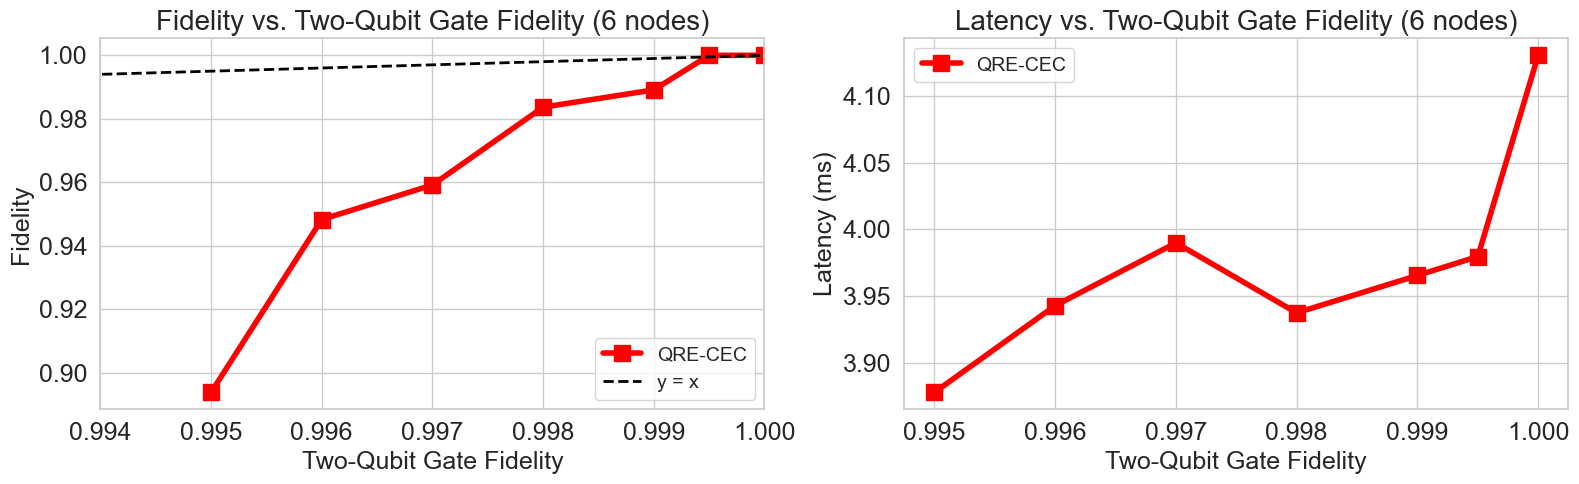

   nodes  two_qubit_gate_fidelity correction_mode  mean_fidelity_corrected  \
0      6                   0.9950             cec                 0.893733   
1      6                   0.9960             cec                 0.948229   
2      6                   0.9970             cec                 0.959128   
3      6                   0.9980             cec                 0.983651   
4      6                   0.9990             cec                 0.989101   
5      6                   0.9995             cec                 1.000000   
6      6                   1.0000             cec                 1.000000   

   mean_latency_ms  
0         3.877766  
1         3.942782  
2         3.989804  
3         3.937373  
4         3.965407  
5         3.979591  
6         4.130391  

Using log_dir: /Users/patange/Documents/Argonne/QEC/log/runner-ideal/test_graph_one_qubit_gate_sweep
Exists: True
row_count: 2100
raw_points:
                                               log_name  nodes  

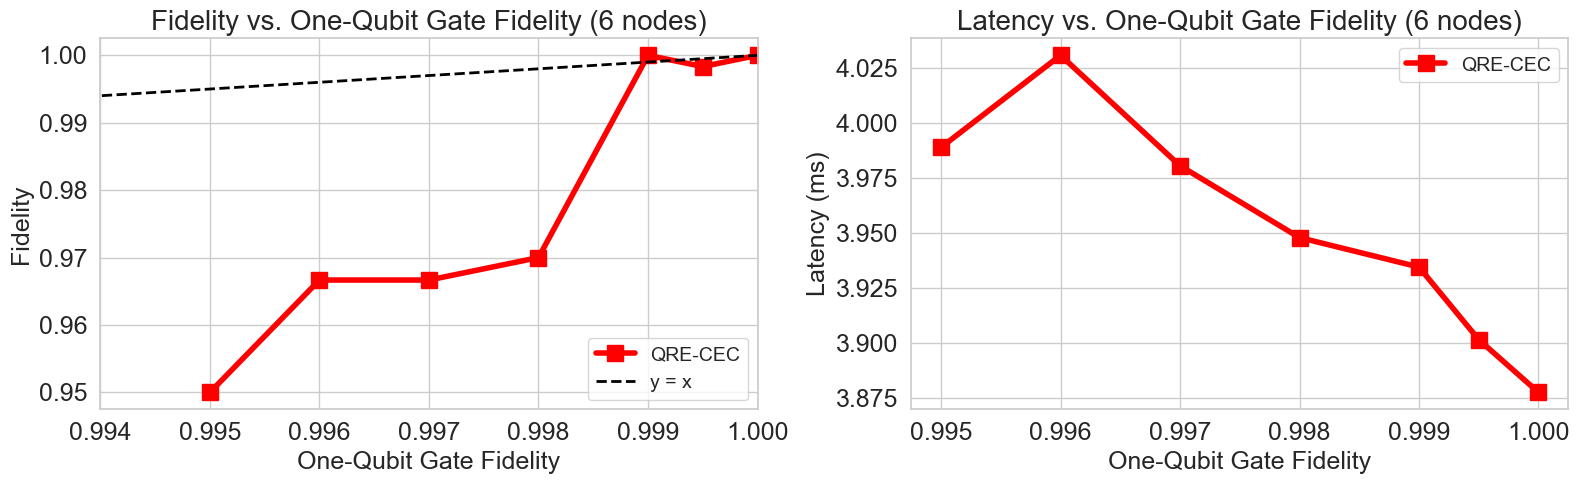

   nodes  gate_fidelity correction_mode  mean_fidelity_corrected  \
0      6         0.9950             cec                 0.950000   
1      6         0.9960             cec                 0.966667   
2      6         0.9970             cec                 0.966667   
3      6         0.9980             cec                 0.970000   
4      6         0.9990             cec                 1.000000   
5      6         0.9995             cec                 0.998333   
6      6         1.0000             cec                 1.000000   

   mean_latency_ms  
0         3.989136  
1         4.030967  
2         3.980757  
3         3.948116  
4         3.934715  
5         3.901742  
6         3.877757  

Using log_dir: /Users/patange/Documents/Argonne/QEC/log/runner-ideal/test_graph_measurement_fidelity_sweep
Exists: True
row_count: 2148
raw_points:
                                               log_name  nodes  \
0     line_6_2G,code=[[7,1,3]],dist=1.0,gate=1.0,two...      6   
1     

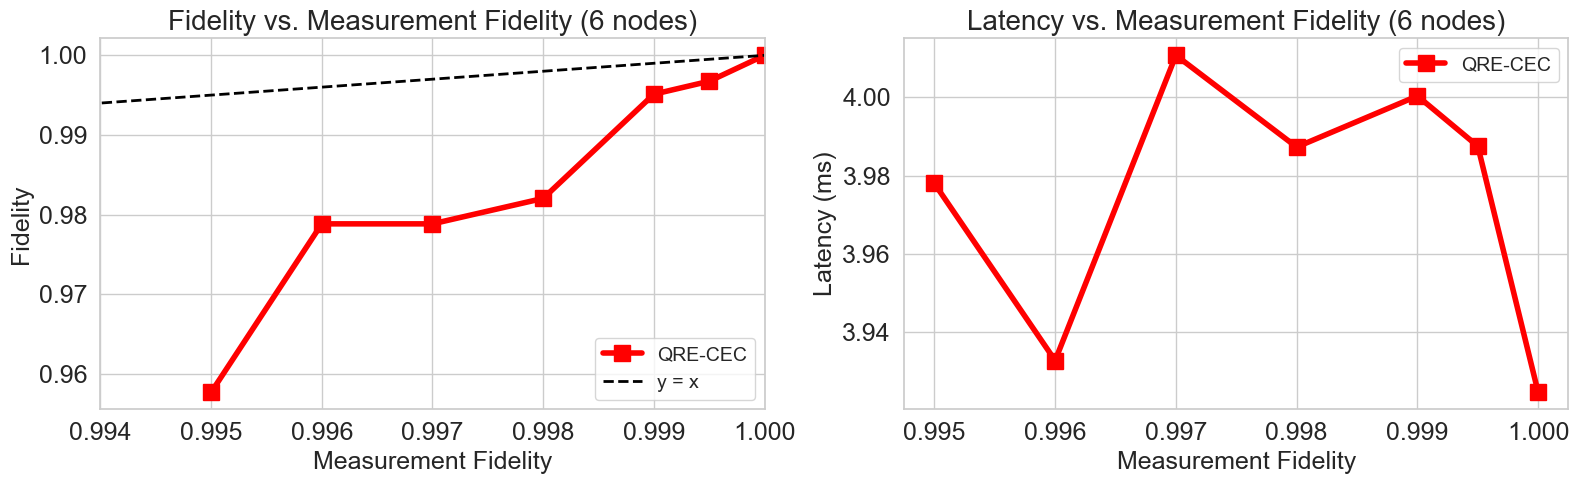

   nodes  measurement_fidelity correction_mode  mean_fidelity_corrected  \
0      6                0.9950             cec                 0.957655   
1      6                0.9960             cec                 0.978827   
2      6                0.9970             cec                 0.978827   
3      6                0.9980             cec                 0.982026   
4      6                0.9990             cec                 0.995114   
5      6                0.9995             cec                 0.996743   
6      6                1.0000             cec                 1.000000   

   mean_latency_ms  
0         3.977986  
1         3.932713  
2         4.010746  
3         3.987290  
4         4.000357  
5         3.987515  
6         3.924570  


In [4]:
project_dir = Path.cwd()
if not (project_dir / "log").exists() and (project_dir / "QEC" / "log").exists():
    project_dir = project_dir / "QEC"

output_dir = project_dir / "plot_pngs"
output_dir.mkdir(parents=True, exist_ok=True)

experiment_configs = [
    {
        "folder": "test_graph_two_qubit_gate_sweep",
        "x_column": "two_qubit_gate_fidelity",
        "x_label": "Two-Qubit Gate Fidelity",
        "png_name": "test_graph_two_qubit_gate_sweep.png",
    },
    {
        "folder": "test_graph_one_qubit_gate_sweep",
        "x_column": "gate_fidelity",
        "x_label": "One-Qubit Gate Fidelity",
        "png_name": "test_graph_one_qubit_gate_sweep.png",
    },
    {
        "folder": "test_graph_measurement_fidelity_sweep",
        "x_column": "measurement_fidelity",
        "x_label": "Measurement Fidelity",
        "png_name": "test_graph_measurement_fidelity_sweep.png",
    },
]

colors = {"cec": "red", "none": "blue", "qec": "green", "qec+cec": "purple"}
names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC", "qec+cec": "QRE-QEC+CEC"}
markers = {"cec": "s", "none": "^", "qec": "o", "qec+cec": "D"}

for config in experiment_configs:
    log_dir = project_dir / "log" / "runner-ideal" / config["folder"]

    print("\nUsing log_dir:", log_dir)
    print("Exists:", log_dir.exists())

    test_df = load_runner_logs(log_dir)

    print("row_count:", len(test_df))
    if not test_df.empty:
        columns_to_show = [
            "log_name",
            "nodes",
            config["x_column"],
            "correction_mode",
            "fidelity_corrected",
            "latency_ms",
        ]
        print("raw_points:")
        print(test_df[columns_to_show].sort_values(["nodes", config["x_column"], "correction_mode", "log_name"]))
        print("nodes:", sorted(test_df["nodes"].unique()))
        print("modes:", sorted(test_df["correction_mode"].unique()))
        print("x_values:", sorted(test_df[config["x_column"]].dropna().unique()))

    if test_df.empty:
        print(f"No {config['folder']} data found.")
        continue

    summary = (
        test_df.groupby(["nodes", config["x_column"], "correction_mode"], as_index=False)
        .agg(
            mean_fidelity_corrected=("fidelity_corrected", "mean"),
            mean_latency_ms=("latency_ms", "mean"),
        )
        .sort_values(["nodes", config["x_column"], "correction_mode"])
        .reset_index(drop=True)
    )

    print("figure_points:")
    print(summary)

    node_values = sorted(summary["nodes"].unique())
    fig, axes = plt.subplots(len(node_values), 2, figsize=(16, 5 * len(node_values)), squeeze=False)

    for row_index, node_count in enumerate(node_values):
        node_data = summary[summary["nodes"] == node_count]
        ax0 = axes[row_index][0]
        ax1 = axes[row_index][1]

        for protocol in sorted(node_data["correction_mode"].unique()):
            data = node_data[node_data["correction_mode"] == protocol]
            ax0.plot(
                data[config["x_column"]],
                data["mean_fidelity_corrected"],
                color=colors.get(protocol, "black"),
                marker=markers.get(protocol, "o"),
                linewidth=4,
                markersize=12,
                linestyle="-",
                label=names.get(protocol, protocol),
            )
            ax1.plot(
                data[config["x_column"]],
                data["mean_latency_ms"],
                color=colors.get(protocol, "black"),
                marker=markers.get(protocol, "o"),
                linewidth=4,
                markersize=12,
                label=names.get(protocol, protocol),
            )

        lower = min(node_data[config["x_column"]].min(), node_data["mean_fidelity_corrected"].min())
        upper = max(node_data[config["x_column"]].max(), node_data["mean_fidelity_corrected"].max())
        ax0.plot([lower, upper], [lower, upper], color="black", linestyle="--", linewidth=2, label="y = x")

        ax0.set_xlabel(config["x_label"], fontsize=18)
        ax0.set_ylabel("Fidelity", fontsize=18)
        ax0.set_title(f"Fidelity vs. {config['x_label']} ({node_count} nodes)", fontsize=20)
        ax0.tick_params(axis="both", labelsize=18)
        ax0.legend(fontsize=14)
        ax0.set_xlim(0.994, 1.0)

        ax1.set_xlabel(config["x_label"], fontsize=18)
        ax1.set_ylabel("Latency (ms)", fontsize=18)
        ax1.set_title(f"Latency vs. {config['x_label']} ({node_count} nodes)", fontsize=20)
        ax1.tick_params(axis="both", labelsize=18)
        ax1.legend(fontsize=14)

    plt.tight_layout()
    plt.savefig(output_dir / config["png_name"], dpi=300, bbox_inches="tight")
    plt.show()

    print(summary)
